# 02 - MIMIC-IV-ECG exploratory data analysis

MIMIC-IV-ECG is the largest source in the project. About 39,000 of its recordings make up
most of the frozen 56,875-record pretraining pool, and the local copy has 200,000. It is used
**only for self-supervised pretraining**: no MIMIC label enters any model. So the questions
differ from PTB-XL. There are no label rules to audit. Instead we ask whether the selection is
unbiased, whether the waveforms are read correctly, and how the signals differ from PTB-XL.

Everything is computed from the raw PhysioNet release in `data/raw/mimic-iv-ecg/1.0/`: the
official `record_list.csv`, `machine_measurements.csv` and the WFDB waveform files.

**Data use.** MIMIC is credentialed data. This notebook only shows aggregate statistics and never
prints individual records, identifiers or waveforms, so its outputs can be kept in the repository.

The previous notebook established what a clean ECG looks like in our statistics (PTB-XL), and
validated the noise measures against human annotations. We reuse those as the reference.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eda.mimic import (
    load_machine_measurements,
    load_records,
    measured_intervals,
    mimic_summary,
    nan_profile,
    project_accepted,
    read_signal_by_position,
    stored_lead_orders,
)
from eda.ptbxl import load_metadata
from eda.ptbxl_signals import ptbxl_summary
from eda.signals import LEADS, problem_counts, signal_features

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

records = load_records()
measurements = load_machine_measurements()

## 1. The full release and the local subset

The official release has about 800,000 ECGs. The project downloaded a subset of whole patients,
chosen by a seeded hash of the patient ID. We check the sizes, that every selected patient is
complete, and that the subset looks like the rest of the release.

In [3]:
local = records[records["downloaded"]]
display(pd.Series({
    "records in release": len(records),
    "patients in release": records["subject_id"].nunique(),
    "records on disk": len(local),
    "patients on disk": local["subject_id"].nunique(),
    "on disk, not selected": int((records["downloaded"] & ~records["project_selected"]).sum()),
    "selected, not on disk": int((~records["downloaded"] & records["project_selected"]).sum()),
}).to_frame("count"))

per_patient = records.groupby("subject_id").agg(records=("path", "size"), local_share=("downloaded", "mean"))
partial = ((per_patient["local_share"] > 0) & (per_patient["local_share"] < 1)).sum()
print(f"Patients with only part of their records on disk: {partial}")
display(per_patient.groupby(per_patient["local_share"] > 0)["records"].describe()
        .rename(index={False: "not selected", True: "selected"}).round(2))

,count
records in release,800035
patients in release,161352
records on disk,200000
patients on disk,40696
"on disk, not selected",0
"selected, not on disk",0


Patients with only part of their records on disk: 0


,count,mean,std,min,25%,50%,75%,max
local_share,,,,,,,,
not selected,120656.0,4.97,8.13,1.0,1.0,2.0,5.0,260.0
selected,40696.0,4.91,7.91,1.0,1.0,2.0,5.0,217.0


In [4]:
joined = records.join(measurements[["overall", "filtering", "bandwidth"]])
for column in ("overall", "filtering"):
    table = pd.crosstab(joined[column], joined["downloaded"], normalize="columns")
    display(table.rename(columns={False: "not selected", True: "selected"}).round(3))

downloaded,not selected,selected
overall,,
Abnormal ECG,0.445,0.442
Borderline ECG,0.214,0.215
Normal ECG,0.193,0.196
no statement,0.147,0.146


downloaded,not selected,selected
filtering,,
50 Hz notch Baseline filter,0.003,0.003
60 Hz notch Baseline filter,0.847,0.847
<not specified>,0.134,0.134
Baseline filter,0.016,0.016


**Finding: the subset is a fair random sample of whole patients.** 200,000 records from 40,696
patients are on disk, exactly the project's selection. No patient is split. Selected and
unselected patients have the same distribution of ECGs per patient (median 2, mean about 4.9), the
same mix of machine interpretations (44% abnormal, 21% borderline, 20% normal) and the same filter
settings. The seeded-hash selection behaves like simple random sampling, as intended.

## 2. Machine measurements

`machine_measurements.csv` holds the ECG cart's automatic report lines and interval measurements.
They are not cardiologist diagnoses. The project does not use them for training, but they tell us
how the recordings were acquired and give an independent check of our heart-rate estimate.

In [5]:
display(pd.Series({"rows": len(measurements),
                   "rows matching record_list": measurements.index.isin(records.index).sum(),
                   "carts (devices)": measurements["cart_id"].nunique()}).to_frame("count"))
intervals = measured_intervals(measurements)
columns = intervals.columns.drop("heart_rate")
display(pd.DataFrame({"NaN in the file": measurements[columns].isna().mean(),
                      "exactly 29999": (measurements[columns] == 29999).mean(),
                      "missing after cleaning": intervals[columns].isna().mean()}).round(3))

,count
rows,800035
rows matching record_list,800035
carts (devices),156


,NaN in the file,exactly 29999,missing after cleaning
rr_interval,0.0,0.002,0.002
p_onset,0.0,0.154,0.154
p_end,0.0,0.288,0.288
qrs_onset,0.0,0.001,0.001
qrs_end,0.0,0.002,0.002
t_end,0.0,0.002,0.002
p_axis,0.0,0.154,0.164
qrs_axis,0.0,0.003,0.004
t_axis,0.0,0.003,0.006


**Finding: there are no NaNs, but there is a hidden missing-value code.** Every interval column is
filled in, yet 29999 means "not measured". 29% of `p_end` and 15% of `p_onset` are coded this way.
That is expected, since P waves are absent in atrial fibrillation and hard to detect in noisy
recordings. A few other impossible values also occur (RR intervals of 0, timings just above 29000 ms,
axes of -32768), so `eda.mimic.measured_intervals` masks everything outside a plausible range. Taken
at face value, the code would make the average P-wave end about 9 seconds.

,count,mean,std,min,1%,50%,99%,max
rr_interval,798506.0,816.7,197.0,235.0,422.0,810.0,1333.0,5454.0
p_onset,676601.0,88.0,119.6,0.0,40.0,40.0,390.0,9364.0
p_end,569670.0,149.7,124.3,0.0,102.0,150.0,188.0,27136.0
qrs_onset,798903.0,241.3,112.7,0.0,122.0,200.0,507.0,9998.0
qrs_end,798695.0,341.5,169.6,0.0,214.0,302.0,649.0,28672.0
t_end,798691.0,639.3,126.9,235.0,428.0,610.0,976.0,9630.0
p_axis,669023.0,45.7,30.8,-180.0,-59.0,51.0,106.0,285.0
qrs_axis,796471.0,13.4,45.8,-180.0,-95.0,13.0,121.0,269.0
t_axis,795428.0,40.7,57.2,-252.0,-159.0,42.0,172.0,269.0
heart_rate,798506.0,78.0,20.3,11.0,45.0,74.1,142.2,255.3


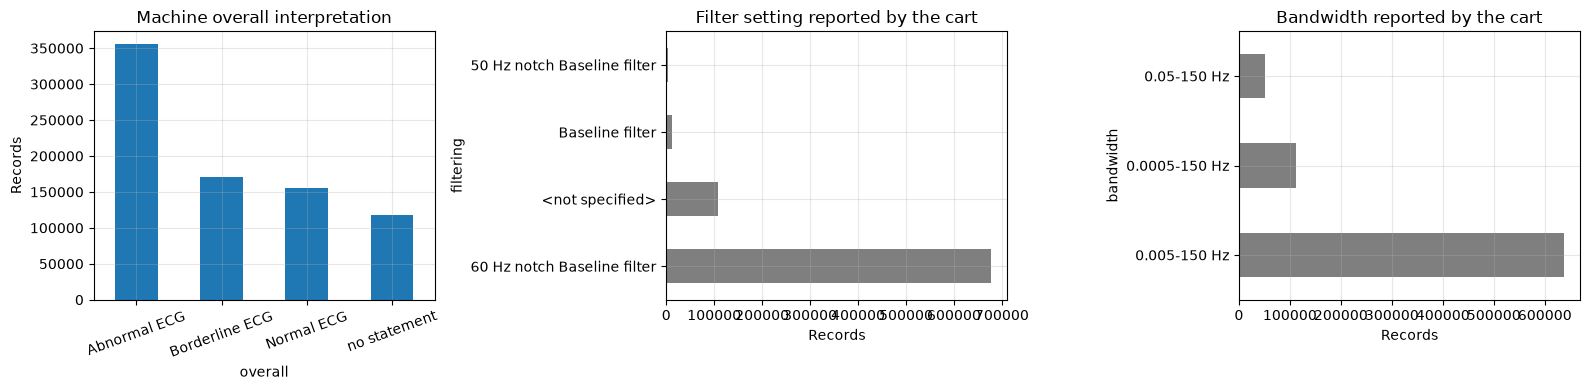

,records with this report line
report,
Abnormal ECG,355656
Sinus rhythm,324175
Borderline ECG,171372
Normal ECG,116608
Left axis deviation,75280
Sinus rhythm.,62443
Sinus bradycardia,60062
Sinus tachycardia,42002
Inferior infarct - age undetermined,41581


In [6]:
display(intervals.describe(percentiles=[0.01, 0.5, 0.99]).T.round(1))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
measurements["overall"].value_counts().plot.bar(ax=axes[0], rot=20, color="tab:blue")
axes[0].set(title="Machine overall interpretation", ylabel="Records")
measurements["filtering"].value_counts().plot.barh(ax=axes[1], color="tab:gray")
axes[1].set(title="Filter setting reported by the cart", xlabel="Records")
measurements["bandwidth"].value_counts().plot.barh(ax=axes[2], color="tab:gray")
axes[2].set(title="Bandwidth reported by the cart", xlabel="Records")
plt.tight_layout()
plt.show()
lines = measurements["report"].str.split(" | ", regex=False).explode()
display(lines.value_counts().head(20).to_frame("records with this report line"))

**Finding.** Once the codes are removed, the intervals are physiological (median heart rate 74 bpm,
median QRS duration 94 ms).
Three details matter for the rest of the notebook:

- The carts report **different filter settings**. Most use a 60 Hz notch plus baseline filter, but
  13% report `<not specified>` and a 0.0005-150 Hz bandwidth, meaning no baseline filtering.
- **15% of records have no overall statement** (normal, borderline or abnormal). Section 4 shows
  both facts come from the same device.
- The report text is rich (infarcts, bundle branch blocks, atrial fibrillation). The project's
  audits use it as a proxy label, which is reasonable for exploration, but it remains a machine
  opinion.

## 3. Lead order

MIMIC headers store the leads as **I, II, III, aVR, aVF, aVL**, with aVF and aVL swapped relative to
the standard order. A loader that stacks channels by position instead of by name would silently
swap two leads in every MIMIC record, and PTB-XL-trained models would then see mislabeled leads.
We check the headers, then show what a positional read would do to the limb-lead identities from
the PTB-XL notebook (aVL = (I - III)/2, aVF = (II + III)/2).

In [7]:
display(stored_lead_orders(records, sample=2000).to_frame("headers"))
rows = []
for path in local["path"].sample(200, random_state=0):
    signal, fs = read_signal_by_position(path)
    features = signal_features(signal, fs)
    rows.append({"aVL identity error (mV)": features["avl_residual"][0],
                 "aVF identity error (mV)": features["avf_residual"][0]})
positional = pd.DataFrame(rows)
summary = mimic_summary(records)
by_name = summary[["avl_residual", "avf_residual"]].median()
display(pd.DataFrame({"read by position": positional.median().to_numpy(),
                      "read by lead name": by_name.to_numpy()},
                     index=["aVL identity error (mV)", "aVF identity error (mV)"]).round(3))

,headers
"I,II,III,aVR,aVF,aVL,V1,V2,V3,V4,V5,V6",2000


,read by position,read by lead name
aVL identity error (mV),1.046,0.01
aVF identity error (mV),1.049,0.01


**Finding: the swap is real and the project handles it correctly.** All 2,000 sampled headers use
the swapped order. Read by position, the aVL and aVF identities are off by about 1.05 mV, roughly
the size of a QRS complex. Read by name (as `eda` does, and as the project's
`ecg_experiment/waveforms.py` does), the error is about 0.01 mV, two quantization steps of 0.005 mV.
The PTB-XL notebook showed the project's MIMIC arrays match the raw files exactly, so this pitfall
was avoided.

## 4. Signal integrity

The same checks as for PTB-XL, run on all 200,000 local records (about 25 minutes, then cached).

In [8]:
display(problem_counts(summary).to_frame("records"))
display(summary["samples"].value_counts().to_frame("records by length"))

,records
records,200000
any_nan,2610
fully_constant_lead,488
lead_flat_for_1s,993
lead_over_10mv,498
limb_identity_violated,23919
heart_rate_not_estimated,177


,records by length
samples,
5000,200000


Compared with PTB-XL, MIMIC has more of everything: NaNs, constant leads and, above all,
**24,000 records (12%) that violate a limb-lead identity**. We take them one at a time.

In [9]:
nan_records = summary[summary["nan_leads"] > 0]
profile = nan_profile(records.loc[nan_records.sample(200, random_state=0).index, "path"].tolist())
display(pd.Series({
    "records with NaN samples": len(nan_records),
    "sampled records with a whole lead missing": int((profile[LEADS] == 5000).any(axis=1).sum()),
    "median NaN samples in an affected lead": float(profile[LEADS].replace(0, np.nan).stack().median()),
}).to_frame("value"))
display(nan_records["nan_leads"].value_counts().sort_index().to_frame("records by number of NaN leads"))
accepted = project_accepted("mimic_ssl_200k")
display(pd.Series({
    "records the project excluded": len(summary) - len(accepted),
    "records with NaN samples": len(nan_records),
    "records with NaN samples that the project kept": len(nan_records.index.intersection(accepted)),
}).to_frame("count"))

,value
records with NaN samples,2610.0
sampled records with a whole lead missing,0.0
median NaN samples in an affected lead,19.0


,records by number of NaN leads
nan_leads,
1,2035
2,202
3,133
4,52
5,57
6,28
7,10
8,10
9,8


,count
records the project excluded,2793
records with NaN samples,2610
records with NaN samples that the project kept,0


**Finding: NaNs are short gaps, and the project removes all of them.** 2,610 records (1.3%) contain
NaN samples. In 78% of them only one lead is affected, and the typical gap is short (median 19
samples, 0.04 s). No sampled record lost a whole lead. The
project excludes every one of these records and 183 exact duplicates, and nothing else. Its
exclusion count matches ours exactly. Dropping whole records is conservative but fine at this scale.

In [10]:
summary = summary.join(measurements[["cart_id", "filtering", "bandwidth", "overall"]])
identities = ["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]
finite = summary[summary["nan_leads"] == 0].copy()
finite["identity_violated"] = finite[identities].max(axis=1) > 0.05
by_cart = finite.groupby("cart_id")["identity_violated"].agg(records="size", violation_rate="mean")
display(by_cart.sort_values("violation_rate", ascending=False).head(5).round(3))
odd_cart = by_cart["violation_rate"].idxmax()
finite["cart"] = np.where(finite["cart_id"] == odd_cart, "cart with violations", "all other carts")
display(finite.groupby("cart")[identities].median().round(3))
display(pd.crosstab(finite["cart"], finite["overall"], normalize="index").round(3))
display(pd.crosstab(finite["cart"], finite["bandwidth"], normalize="index").round(3))

,records,violation_rate
cart_id,,
6632385,26707,0.840
6087615,144,0.069
6924724,882,0.043
6263029,101,0.030
6193783,110,0.018


,einthoven_residual,avf_residual,avl_residual,avr_residual
cart,,,,
all other carts,0.01,0.01,0.01,0.01
cart with violations,0.08,0.05,0.05,0.04


overall,Abnormal ECG,Borderline ECG,Normal ECG,no statement
cart,,,,
all other carts,0.509,0.249,0.228,0.014
cart with violations,0.000,0.000,0.000,1.000


bandwidth,0.0005-150 Hz,0.005-150 Hz,0.05-150 Hz
cart,,,
all other carts,0.005,0.921,0.073
cart with violations,1.000,0.000,0.000


**Finding: one device behaves differently.** Almost all identity violations come from a single cart,
which recorded 26,707 of the local records (13%). Its violation rate is 84%, against about 1% for
every other cart. The violations are small (median 0.05-0.08 mV), so leads are not swapped. Rather,
this device does not store its limb leads as exact combinations of I and II, probably because it
filters or quantizes each lead separately. The same cart is the one that reports `<not specified>`
filtering and the 0.0005-150 Hz bandwidth, and it **never produces a machine interpretation**
(100% "no statement").

For self-supervised pretraining this is harmless, but it is a distinct sub-population. A model
trained to exploit exact lead relationships (such as the project's cross-lead experiments) will see
two kinds of MIMIC recordings. It is worth tracking this cart as a covariate.

In [11]:
constant = summary[summary["constant_leads"] > 0]
accepted_40k = project_accepted("mimic_ssl_40k_cpc")
display(pd.Series({
    "records with a fully constant lead": len(constant),
    "... kept in the project's 200k manifest": len(constant.index.intersection(accepted)),
    "... kept in the 40k manifest used by the frozen pool": len(constant.index.intersection(accepted_40k)),
    "records with a lead flat for 1 s or more": int((summary["flat_leads"] > 0).sum()),
}).to_frame("count"))

,count
records with a fully constant lead,488
... kept in the project's 200k manifest,307
... kept in the 40k manifest used by the frozen pool,65
records with a lead flat for 1 s or more,993


**Finding: constant leads are not removed from the MIMIC manifests.** 488 records have a lead that
is constant for the full 10 seconds (a disconnected electrode). The project's MIMIC audit only drops
the ones that also contain NaNs, so 307 remain in the 200k manifest and 65 in the 40k manifest. The
later union build found and removed those 65, but the frozen 56,875-record pool (`cpc_pool_40k`) was
built from the 40k manifest, and all 65 are still in the pool every CPC experiment trained on. The effect is small (0.1% of the pool) but it is
an inconsistency: the same record is excluded from one dataset and included in the other.

## 5. Signal distributions compared with PTB-XL

With integrity understood, how do MIMIC signals compare with PTB-XL? We also use the machine RR
intervals to validate the heart-rate estimator that the PTB-XL notebook relied on.

,estimated vs machine
records compared,199587.000
median absolute error (bpm),0.542
within 5 bpm,0.937
correlation,0.981


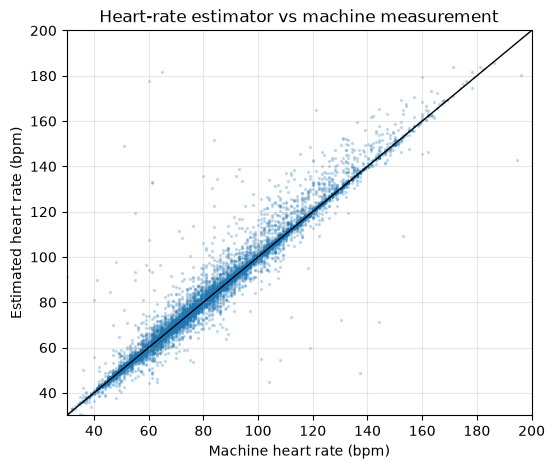

In [12]:
paired = summary[["heart_rate"]].join(intervals["heart_rate"].rename("machine_heart_rate")).dropna()
error = paired["heart_rate"] - paired["machine_heart_rate"]
display(pd.Series({"records compared": len(paired),
                   "median absolute error (bpm)": error.abs().median(),
                   "within 5 bpm": (error.abs() <= 5).mean(),
                   "correlation": paired.corr().iloc[0, 1]}).to_frame("estimated vs machine").round(3))
fig, ax = plt.subplots(figsize=(6, 5))
sample = paired.sample(20000, random_state=0)
ax.scatter(sample["machine_heart_rate"], sample["heart_rate"], s=2, alpha=0.2)
ax.plot([30, 200], [30, 200], color="black", linewidth=1)
ax.set(xlim=(30, 200), ylim=(30, 200), xlabel="Machine heart rate (bpm)",
       ylabel="Estimated heart rate (bpm)", title="Heart-rate estimator vs machine measurement")
plt.show()

**Finding: the heart-rate estimator is reliable.** Against the machine measurements of about 200,000
records, the median error is about 0.5 bpm, 94% of estimates are within 5 bpm, and the correlation is
0.98. The heart-rate findings in the PTB-XL notebook (the 43-117 bpm window of the negatives) stand.

,PTB-XL,MIMIC
std,1.525e-01,1.326e-01
peak_abs_mv,1.905e+00,1.635e+00
baseline_fraction,1.990e-02,8.300e-03
high_frequency_fraction,6.600e-03,1.120e-02
powerline_50_fraction,7.000e-04,1.000e-03
powerline_60_fraction,3.000e-04,5.000e-04
heart_rate,7.126e+01,7.463e+01


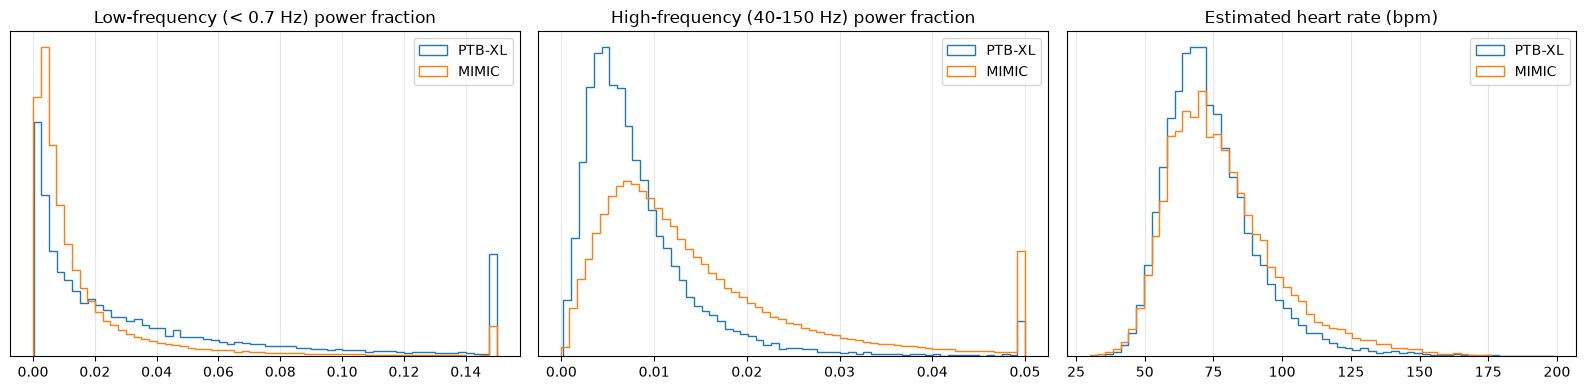

In [13]:
ptbxl = ptbxl_summary(load_metadata())
metrics = ["std", "peak_abs_mv", "baseline_fraction", "high_frequency_fraction",
           "powerline_50_fraction", "powerline_60_fraction", "heart_rate"]
comparison = pd.DataFrame({"PTB-XL": ptbxl[metrics].median(), "MIMIC": summary[metrics].median()})
display(comparison.round(4))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
style = {"bins": 60, "density": True, "histtype": "step"}
for name, table in (("PTB-XL", ptbxl), ("MIMIC", summary)):
    axes[0].hist(table["baseline_fraction"].clip(upper=0.15), label=name, **style)
    axes[1].hist(table["high_frequency_fraction"].clip(upper=0.05), label=name, **style)
    axes[2].hist(table["heart_rate"].clip(30, 200), label=name, **style)
titles = ["Low-frequency (< 0.7 Hz) power fraction", "High-frequency (40-150 Hz) power fraction",
          "Estimated heart rate (bpm)"]
for axis, title in zip(axes, titles, strict=True):
    axis.set(title=title, yticks=[])
    axis.legend()
plt.tight_layout()
plt.show()

**Finding: MIMIC is filtered differently and comes from a sicker population.** Compared with
PTB-XL, MIMIC has less than half the low-frequency power (most carts apply a baseline filter), about
1.7x more power above 40 Hz (muscle noise and a wider recording bandwidth), slightly smaller
amplitudes, and slightly faster heart rates, as expected for hospital and emergency patients. Mains
interference is negligible in both. None of this is a problem for pretraining, but it means **a model
can tell MIMIC from PTB-XL by noise characteristics alone**. That matters if MIMIC and PTB-XL
recordings are ever mixed in a supervised or evaluation setting. The cross-dataset notebook
quantifies how identifiable each source is.

## 6. Conclusions

**What is correct**

- The 200,000-record subset is a fair random sample of whole patients, and the frozen 40k subset is
  its exact prefix.
- The swapped aVF/aVL lead order in MIMIC headers is handled correctly, and the project's arrays
  match the raw files.
- All records with NaN samples are excluded; the project's exclusion counts match ours exactly.

**What needs attention**

1. **Constant leads remain in the MIMIC manifests and the frozen pool.** 307 records in the 200k
   manifest and 65 in the 40k manifest have a fully constant lead. The union build removes them, but
   the frozen `cpc_pool_40k` does not. *Recommendation:* apply the same constant-lead rule to every
   MIMIC manifest.
2. **One cart (13% of records) is a distinct sub-population**: inexact limb leads, no baseline
   filter, no machine interpretation. *Recommendation:* keep `cart_id` as a covariate and check it
   when a model relies on lead relationships.
3. **`machine_measurements.csv` hides missing values as 29999** (plus a few other impossible
   values). Clean them before any use.
4. **MIMIC is identifiable from noise statistics** (baseline filtering, high-frequency content). This is
   harmless for pretraining, but it should not be mixed with PTB-XL for supervised evaluation.

Next, the Challenge sources (Georgia, CPSC 2018, CPSC-Extra and Chapman/Shaoxing), which the union
dataset adds to pretraining.